# Mamba-Enhanced Physics-Informed Multi-Output Autoencoder
## NASA Reentry CFD Surrogate Model

**Architecture:** Mamba-2 SSM encoder with Mamba-3 extensions (RoPE trick + trapezoidal discretization)

**Key improvements over baseline autoencoder:**
1. **Spatial sequence processing** — surface mesh points processed as an ordered sequence, capturing neighbor correlations
2. **Multi-output prediction** — jointly predicts qw (heat flux), pw (pressure), τw (shear stress)
3. **Physics coupling losses** — Reynolds analogy, pressure bounds, positivity constraints
4. **Mamba-3 tricks** — complex-valued RoPE for oscillatory dynamics, trapezoidal discretization for sharp gradients
5. **Modular design** — swap `block_type` between `mamba2`, `mamba3`, or `mlp` via config

**Requirements:** Google Colab with GPU runtime (T4)

In [1]:
# ============================================================
# Cell 0: Setup & Configuration
# ============================================================
import os, math, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Literal
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA H100 80GB HBM3
VRAM: 85.0 GB


In [2]:
# ============================================================
# Cell 1: Configuration (EDIT THIS CELL)
# ============================================================
@dataclass
class Config:
    # --- Data ---
    points_per_solution: int = 50176        # raw mesh points per CFD solution
    seq_len: int = 4096                     # downsampled points per solution for Mamba
    train_frac: float = 0.80
    val_frac: float = 0.10

    # --- Model ---
    block_type: str = "mamba3"              # "mamba2", "mamba3", or "mlp"
    d_model: int = 64                       # hidden dimension
    d_state: int = 64                       # SSM state dimension
    d_conv: int = 4                         # local conv width
    n_layers: int = 4                       # number of Mamba/MLP blocks
    latent_dim: int = 16                    # autoencoder bottleneck
    expand: int = 2                         # Mamba expand factor
    use_rope: bool = True                   # Mamba-3: complex-valued RoPE
    use_trapezoidal: bool = True            # Mamba-3: trapezoidal discretization

    # --- Outputs ---
    predict_qw: bool = True                 # heat flux
    predict_pw: bool = False                 # wall pressure
    predict_tw: bool = False                 # shear stress

    # --- Physics losses ---
    lambda_recon: float = 0.2               # reconstruction loss weight
    lambda_physics: float = 0.1             # physics coupling loss weight
    lambda_reynolds: float = 0.05           # Reynolds analogy weight

    # --- Training ---
    batch_size: int = 4                     # solutions per batch
    lr: float = 1e-3
    weight_decay: float = 8e-3
    epochs: int = 290
    patience: int = 20

    @property
    def n_outputs(self):
        return sum([self.predict_qw, self.predict_pw, self.predict_tw])

cfg = Config()
print(f"Block type: {cfg.block_type}")
print(f"Sequence length: {cfg.seq_len} points per solution")
print(f"Outputs: {cfg.n_outputs} (qw={cfg.predict_qw}, pw={cfg.predict_pw}, τw={cfg.predict_tw})")
print(f"Mamba-3 RoPE: {cfg.use_rope}, Trapezoidal: {cfg.use_trapezoidal}")

Block type: mamba3
Sequence length: 4096 points per solution
Outputs: 1 (qw=True, pw=False, τw=False)
Mamba-3 RoPE: True, Trapezoidal: True


In [3]:
# ============================================================
# Cell 2: Data Loading & Cleaning
# ============================================================
try:
    from google.colab import drive
    drive.mount('/content/drive')
    file_path = "/content/drive/MyDrive/apollo_cfd_database.csv"
except Exception:
    file_path = "apollo_cfd_database.csv"

POINTS_PER_LOCATION = cfg.points_per_solution

df_raw = pd.read_csv(file_path)
print(f"Raw dataset shape: {df_raw.shape}")

n_rows_raw = len(df_raw)
assert n_rows_raw % POINTS_PER_LOCATION == 0, (
    f"Raw row count {n_rows_raw} must be a multiple of {POINTS_PER_LOCATION}"
)
n_locations = n_rows_raw // POINTS_PER_LOCATION
print(f"Detected solutions: {n_locations}")

df_raw = df_raw.copy()
df_raw["location_id"] = (np.arange(n_rows_raw) // POINTS_PER_LOCATION).astype(np.int32)

# --- Random split by solution ---
unique_locs = df_raw["location_id"].unique()
rng = np.random.RandomState(123)
rng.shuffle(unique_locs)

n = len(unique_locs)
n_train = int(round(cfg.train_frac * n))
n_val   = int(round(cfg.val_frac * n))

train_locs = set(unique_locs[:n_train])
val_locs   = set(unique_locs[n_train:n_train + n_val])
test_locs  = set(unique_locs[n_train + n_val:])

split_map = {}
for lid in train_locs: split_map[lid] = "train"
for lid in val_locs:   split_map[lid] = "val"
for lid in test_locs:  split_map[lid] = "test"
df_raw["split"] = df_raw["location_id"].map(split_map)

print("RAW split counts:")
print(df_raw["split"].value_counts(dropna=False))

# --- Cleaning ---
df_clean = df_raw.copy()
df_clean = df_clean[df_clean['theta (m)'] >= 0]
df_clean = df_clean[df_clean['Re-theta'] >= 1e-5]
df_clean = df_clean[(df_clean['qw (W/m^2)'] >= 1e3) & (df_clean['qw (W/m^2)'] <= 1e7)]

print(f"After cleaning: {len(df_clean):,} rows; "
      f"solutions present: {df_clean['location_id'].nunique()}")

Mounted at /content/drive
Raw dataset shape: (9282560, 15)
Detected solutions: 185
RAW split counts:
split
train    7426048
test      953344
val       903168
Name: count, dtype: int64
After cleaning: 9,106,059 rows; solutions present: 185


In [4]:
# ============================================================
# Cell 3: Spatial Ordering & Sequence Dataset Construction
# ============================================================

# Feature and target columns
X_cols = ['X', 'Y', 'Z',
          'velocity (m/s)', 'density (kg/m^3)',
          'aoa (degrees)', 'dynamic_pressure (Pa)']

# Target columns (multi-output)
y_cols = []
y_col_names = []
if cfg.predict_qw:
    y_cols.append('qw (W/m^2)')
    y_col_names.append('qw')
if cfg.predict_pw:
    y_cols.append('pw (Pa)')
    y_col_names.append('pw')
if cfg.predict_tw:
    y_cols.append('tauw (Pa)')
    y_col_names.append('tw')

print(f"Input features: {X_cols}")
print(f"Target outputs: {y_cols}")


def spatial_sort_solution(df_sol):
    """
    Sort mesh points by spatial ordering on the capsule surface.
    Uses geodesic angle from symmetry axis + azimuthal angle
    to create a spiral scan path across the surface.
    """
    x, y, z = df_sol['X'].values, df_sol['Y'].values, df_sol['Z'].values
    # Polar angle from symmetry axis (X-axis for Apollo capsule)
    r_perp = np.sqrt(y**2 + z**2)
    theta_geo = np.arctan2(r_perp, x)
    # Azimuthal angle
    phi = np.arctan2(z, y)
    # Create composite sort key: primary by theta bands, secondary by phi
    n_bands = 64  # number of latitude bands
    theta_band = np.digitize(theta_geo, np.linspace(0, np.pi, n_bands + 1)) - 1
    sort_idx = np.lexsort((phi, theta_band))
    return sort_idx


def downsample_solution(features, targets, n_points):
    """
    Evenly downsample a spatially-sorted solution to n_points.
    Uses strided sampling to preserve spatial coverage.
    """
    total = len(features)
    if total <= n_points:
        # Pad with last point if fewer than n_points
        pad_len = n_points - total
        features = np.concatenate([features, np.tile(features[-1:], (pad_len, 1))], axis=0)
        targets  = np.concatenate([targets,  np.tile(targets[-1:],  (pad_len, 1))], axis=0)
        return features, targets
    # Strided sampling preserves spatial coverage
    idx = np.linspace(0, total - 1, n_points, dtype=int)
    return features[idx], targets[idx]


# Build per-solution sequences
print("Building solution sequences...")

def build_sequences(df, split_name, seq_len):
    df_split = df[df['split'] == split_name]
    loc_ids = sorted(df_split['location_id'].unique())
    X_seqs, Y_seqs, meta = [], [], []
    for lid in loc_ids:
        sol = df_split[df_split['location_id'] == lid]
        sort_idx = spatial_sort_solution(sol)
        sol_sorted = sol.iloc[sort_idx]
        feats = sol_sorted[X_cols].values.astype(np.float32)
        targs = sol_sorted[y_cols].values.astype(np.float32)
        feats_ds, targs_ds = downsample_solution(feats, targs, seq_len)
        X_seqs.append(feats_ds)
        Y_seqs.append(targs_ds)
        meta.append({'location_id': lid, 'n_points_orig': len(sol)})
    return np.stack(X_seqs), np.stack(Y_seqs), meta

X_train_raw, Y_train_raw, meta_train = build_sequences(df_clean, 'train', cfg.seq_len)
X_val_raw,   Y_val_raw,   meta_val   = build_sequences(df_clean, 'val',   cfg.seq_len)
X_test_raw,  Y_test_raw,  meta_test  = build_sequences(df_clean, 'test',  cfg.seq_len)

print(f"Train: {X_train_raw.shape}  Val: {X_val_raw.shape}  Test: {X_test_raw.shape}")
print(f"Each solution: ({cfg.seq_len} points, {len(X_cols)} features) → ({cfg.seq_len} points, {cfg.n_outputs} targets)")

Input features: ['X', 'Y', 'Z', 'velocity (m/s)', 'density (kg/m^3)', 'aoa (degrees)', 'dynamic_pressure (Pa)']
Target outputs: ['qw (W/m^2)']
Building solution sequences...
Train: (148, 4096, 7)  Val: (18, 4096, 7)  Test: (19, 4096, 7)
Each solution: (4096 points, 7 features) → (4096 points, 1 targets)


In [5]:
# ============================================================
# Cell 4: Scaling & Dataset
# ============================================================

# Flatten for fitting scalers, then reshape back
n_tr, sl, n_feat = X_train_raw.shape
n_targ = Y_train_raw.shape[-1]

scaler_X = StandardScaler()
X_train_flat = X_train_raw.reshape(-1, n_feat)
scaler_X.fit(X_train_flat)

X_train_s = scaler_X.transform(X_train_raw.reshape(-1, n_feat)).reshape(n_tr, sl, n_feat).astype(np.float32)
X_val_s   = scaler_X.transform(X_val_raw.reshape(-1, n_feat)).reshape(X_val_raw.shape[0], sl, n_feat).astype(np.float32)
X_test_s  = scaler_X.transform(X_test_raw.reshape(-1, n_feat)).reshape(X_test_raw.shape[0], sl, n_feat).astype(np.float32)

# Log-transform and standardize targets
scaler_y = StandardScaler()
Y_train_log = np.log10(np.clip(Y_train_raw, 1e-6, None)).astype(np.float32)
Y_val_log   = np.log10(np.clip(Y_val_raw,   1e-6, None)).astype(np.float32)
Y_test_log  = np.log10(np.clip(Y_test_raw,  1e-6, None)).astype(np.float32)

Y_train_flat = Y_train_log.reshape(-1, n_targ)
scaler_y.fit(Y_train_flat)

Y_train_s = scaler_y.transform(Y_train_log.reshape(-1, n_targ)).reshape(n_tr, sl, n_targ).astype(np.float32)
Y_val_s   = scaler_y.transform(Y_val_log.reshape(-1, n_targ)).reshape(Y_val_raw.shape[0], sl, n_targ).astype(np.float32)
Y_test_s  = scaler_y.transform(Y_test_log.reshape(-1, n_targ)).reshape(Y_test_raw.shape[0], sl, n_targ).astype(np.float32)

print(f"Scaled X_train: {X_train_s.shape}, Y_train: {Y_train_s.shape}")


class CFDSolutionDataset(Dataset):
    """Dataset of spatially-ordered CFD solution sequences."""
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


train_ds = CFDSolutionDataset(X_train_s, Y_train_s)
val_ds   = CFDSolutionDataset(X_val_s, Y_val_s)
test_ds  = CFDSolutionDataset(X_test_s, Y_test_s)

train_dl = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,  drop_last=False)
val_dl   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False)
test_dl  = DataLoader(test_ds,  batch_size=1,              shuffle=False)

print(f"DataLoaders ready: {len(train_dl)} train batches, {len(val_dl)} val batches")

Scaled X_train: (148, 4096, 7), Y_train: (148, 4096, 1)
DataLoaders ready: 37 train batches, 5 val batches


In [6]:
# ============================================================
# Cell 5 : Optimized Mamba SSM Core
#
# Three speedups over the original:
#   1. PARALLEL SCAN — replaces sequential for-loop with O(log n)
#      parallel prefix sum. This is the big one.
#   2. torch.compile — JIT compiles the scan for GPU fusion
#   3. AMP-ready — works with mixed precision training
#
# Still includes all Mamba-3 tricks (RoPE, trapezoidal, BC bias).
# ============================================================


def rotate_half(x):
    x1, x2 = x[..., :x.shape[-1]//2], x[..., x.shape[-1]//2:]
    return torch.cat((-x2, x1), dim=-1)


def apply_rope(x, cos, sin):
    return x * cos + rotate_half(x) * sin


def parallel_scan(alpha, inp):
    """
    Parallel associative scan for linear recurrence:
        h_t = alpha_t * h_{t-1} + inp_t

    Uses the work-efficient Blelloch scan in O(log L) parallel steps
    instead of O(L) sequential steps.

    alpha: (B, L, D, N) — decay factors
    inp:   (B, L, D, N) — input terms
    returns: (B, L, D, N) — all hidden states h_1..h_L
    """
    B, L, D, N = alpha.shape

    # Pad to next power of 2
    log2_L = math.ceil(math.log2(L))
    L_pad = 2 ** log2_L
    if L_pad > L:
        pad = L_pad - L
        alpha = F.pad(alpha, (0, 0, 0, 0, 0, pad), value=1.0)  # decay=1 means pass-through
        inp   = F.pad(inp,   (0, 0, 0, 0, 0, pad), value=0.0)

    a = alpha.clone()
    b = inp.clone()

    # Up-sweep (reduce)
    for d in range(log2_L):
        stride = 2 ** (d + 1)
        half = 2 ** d
        idx = torch.arange(half - 1, L_pad, stride, device=alpha.device)
        idx_prev = idx - half + stride - half  # partner indices
        # Clamp to valid range
        idx = idx[idx < L_pad]
        idx_prev = (idx - half).clamp(min=0)

        # (a, b) ⊕ (a', b') = (a * a', a' * b + b')
        a_right = a[:, idx]
        a_left = a[:, idx_prev]
        b_right = b[:, idx]
        b_left = b[:, idx_prev]

        a[:, idx] = a_right * a_left
        b[:, idx] = a_right * b_left + b_right

    # Down-sweep
    a[:, -1] = 1.0
    b[:, -1] = 0.0

    for d in range(log2_L - 1, -1, -1):
        stride = 2 ** (d + 1)
        half = 2 ** d
        idx = torch.arange(half - 1, L_pad, stride, device=alpha.device)
        idx_right = (idx + half).clamp(max=L_pad - 1)

        a_left = a[:, idx].clone()
        b_left = b[:, idx].clone()
        a_right = a[:, idx_right].clone()
        b_right = b[:, idx_right].clone()

        a[:, idx] = a_right
        b[:, idx] = b_right

        a[:, idx_right] = a_left * a_right
        b[:, idx_right] = a_left * b_right + b_left

    # The result is the exclusive prefix scan; shift to get inclusive
    # h_t = alpha_t * prefix_{t-1} + inp_t
    result = alpha * torch.cat([torch.zeros_like(b[:, :1]), b[:, :-1]], dim=1) + inp

    return result[:, :L]  # trim padding


def parallel_scan_simple(alpha, inp):
    """
    Simpler parallel scan using doubling trick.
    More memory but fewer index gymnastics — better for torch.compile.

    h_t = alpha_t * h_{t-1} + inp_t

    Computed via repeated doubling:
      Step k: h_t depends on h_{t-2^k}
    """
    B, L, D, N = alpha.shape
    a = alpha
    b = inp

    # O(log L) doubling steps
    for k in range(math.ceil(math.log2(L))):
        stride = 2 ** k
        # Shift a and b by stride positions
        a_shifted = F.pad(a[:, :-stride], (0,0, 0,0, stride,0), value=0.0)
        b_shifted = F.pad(b[:, :-stride], (0,0, 0,0, stride,0), value=0.0)
        a_shifted[:, :stride] = 1.0  # identity for missing positions

        # Combine: new_a = a * a_shifted, new_b = a * b_shifted + b
        b = a * b_shifted + b
        a = a * a_shifted

    return b


class SelectiveSSM(nn.Module):
    """
    Selective SSM with Mamba-3 extensions + parallel scan.

    Uses parallel_scan_simple for O(log L) computation instead of O(L).
    On H100 with seq_len=512: ~2s vs ~30s per epoch.
    """

    def __init__(self, d_model, d_state=32, d_conv=4, expand=2,
                 use_rope=False, use_trapezoidal=False):
        super().__init__()
        self.d_model = d_model
        self.d_inner = d_model * expand
        self.d_state = d_state
        self.d_conv = d_conv
        self.use_rope = use_rope
        self.use_trapezoidal = use_trapezoidal

        self.in_proj = nn.Linear(d_model, self.d_inner * 2, bias=False)
        self.conv1d = nn.Conv1d(
            self.d_inner, self.d_inner,
            kernel_size=d_conv, padding=d_conv - 1,
            groups=self.d_inner, bias=True
        )
        self.x_proj = nn.Linear(self.d_inner, d_state * 2 + 1, bias=False)
        self.dt_proj = nn.Linear(1, self.d_inner, bias=True)

        A = torch.arange(1, d_state + 1, dtype=torch.float32)
        self.A_log = nn.Parameter(torch.log(A).unsqueeze(0).expand(self.d_inner, -1))

        # Mamba-3: BC bias
        if use_rope or use_trapezoidal:
            self.B_bias = nn.Parameter(torch.ones(d_state))
            self.C_bias = nn.Parameter(torch.ones(d_state))

        if use_rope:
            self.theta_proj = nn.Linear(self.d_inner, d_state // 2, bias=False)
        if use_trapezoidal:
            self.lambda_proj = nn.Linear(self.d_inner, 1, bias=True)

        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
        self.D = nn.Parameter(torch.ones(self.d_inner))

    def _compute_rope(self, x, B, C):
        theta = self.theta_proj(x)
        theta_cum = torch.cumsum(theta, dim=1)
        cos_t = torch.cos(theta_cum).repeat(1, 1, 2)
        sin_t = torch.sin(theta_cum).repeat(1, 1, 2)
        return apply_rope(B, cos_t, sin_t), apply_rope(C, cos_t, sin_t)

    def _parallel_selective_scan(self, x, B, C, delta, A):
        """
        Parallel selective scan using doubling trick.

        Standard:   h_t = α_t * h_{t-1} + Δ_t * B_t * x_t
        Trapezoidal: uses combined input term from current + previous step.
        """
        batch, seq_len, d_inner = x.shape
        N = self.d_state

        # α_t = exp(Δ_t * A)
        alpha = torch.exp(delta.unsqueeze(-1) * A)           # (B, L, D, N)

        # Input term: Δ_t * B_t * x_t
        x_db = x.unsqueeze(-1)                               # (B, L, D, 1)
        B_exp = B.unsqueeze(2)                               # (B, L, 1, N)
        delta_exp = delta.unsqueeze(-1)                      # (B, L, D, 1)
        Bx = B_exp * x_db                                    # (B, L, D, N)

        if self.use_trapezoidal:
            lam = torch.sigmoid(self.lambda_proj(x)).unsqueeze(-1)  # (B, L, 1, 1)
            # Trapezoidal: combine current and previous input terms
            Bx_prev = F.pad(Bx[:, :-1], (0,0, 0,0, 1,0), value=0.0)
            gamma = lam * delta_exp                           # weight for current
            beta = (1 - lam) * delta_exp * alpha              # weight for previous
            inp = gamma * Bx + beta * Bx_prev                 # (B, L, D, N)
        else:
            inp = delta_exp * Bx                              # (B, L, D, N)

        # Parallel scan: h_t = α_t * h_{t-1} + inp_t
        h_all = parallel_scan_simple(alpha, inp)              # (B, L, D, N)

        # Output: y_t = C_t^T * h_t
        C_exp = C.unsqueeze(2)                               # (B, L, 1, N)
        y = (h_all * C_exp).sum(dim=-1)                      # (B, L, D)

        return y

    def forward(self, x):
        batch, seq_len, _ = x.shape

        xz = self.in_proj(x)
        x_ssm, z = xz.chunk(2, dim=-1)

        x_conv = self.conv1d(x_ssm.transpose(1, 2))[:, :, :seq_len]
        x_ssm = F.silu(x_conv.transpose(1, 2))

        ssm_params = self.x_proj(x_ssm)
        B = ssm_params[:, :, :self.d_state]
        C = ssm_params[:, :, self.d_state:2*self.d_state]
        dt = F.softplus(ssm_params[:, :, -1:])

        if hasattr(self, 'B_bias'):
            B = B + self.B_bias
            C = C + self.C_bias

        if self.use_rope:
            B, C = self._compute_rope(x_ssm, B, C)

        delta = F.softplus(self.dt_proj(dt).squeeze(-1))
        A = -torch.exp(self.A_log)

        # PARALLEL scan instead of sequential loop
        y = self._parallel_selective_scan(x_ssm, B, C, delta, A)

        y = y + x_ssm * self.D.unsqueeze(0).unsqueeze(0)
        y = y * F.silu(z)
        return self.out_proj(y)


print("  Optimized SelectiveSSM with PARALLEL SCAN")
print(f"  Mamba-3 RoPE: {cfg.use_rope}")
print(f"  Mamba-3 Trapezoidal: {cfg.use_trapezoidal}")

  Optimized SelectiveSSM with PARALLEL SCAN
  Mamba-3 RoPE: True
  Mamba-3 Trapezoidal: True


In [7]:
# ============================================================
# Cell 6: Full Model Architecture
# ============================================================

class MambaBlock(nn.Module):
    """Pre-norm Mamba block with residual connection."""
    def __init__(self, d_model, d_state, d_conv, expand, use_rope, use_trapezoidal):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.ssm = SelectiveSSM(
            d_model=d_model, d_state=d_state, d_conv=d_conv,
            expand=expand, use_rope=use_rope, use_trapezoidal=use_trapezoidal
        )

    def forward(self, x):
        return x + self.ssm(self.norm(x))


class MLPBlock(nn.Module):
    """Simple MLP block for ablation comparison."""
    def __init__(self, d_model, expand=2):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.net = nn.Sequential(
            nn.Linear(d_model, d_model * expand),
            nn.SiLU(),
            nn.Linear(d_model * expand, d_model)
        )

    def forward(self, x):
        return x + self.net(self.norm(x))


class PredictionHead(nn.Module):
    """Per-output prediction head from latent features."""
    def __init__(self, d_in, d_hidden=64, n_outputs=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, d_hidden),
            nn.SiLU(),
            nn.LayerNorm(d_hidden),
            nn.Linear(d_hidden, n_outputs)
        )

    def forward(self, x):
        return self.net(x)


class MambaAutoencoder(nn.Module):
    """
    Physics-informed multi-output autoencoder with Mamba encoder.

    Architecture:
        Input projection → [Mamba/MLP blocks] → Latent → Decoder heads
                                                       → Prediction heads (qw, pw, τw)
                                                       → Reconstruction head
    """

    def __init__(self, config):
        super().__init__()
        self.config = config
        d = config.d_model

        # Input projection
        self.input_proj = nn.Sequential(
            nn.Linear(len(X_cols), d),
            nn.LayerNorm(d),
            nn.SiLU()
        )

        # Encoder blocks
        if config.block_type in ('mamba2', 'mamba3'):
            use_rope = config.use_rope and config.block_type == 'mamba3'
            use_trap = config.use_trapezoidal and config.block_type == 'mamba3'
            self.encoder = nn.Sequential(*[
                MambaBlock(
                    d_model=d, d_state=config.d_state,
                    d_conv=config.d_conv, expand=config.expand,
                    use_rope=use_rope, use_trapezoidal=use_trap
                ) for _ in range(config.n_layers)
            ])
        elif config.block_type == 'mlp':
            self.encoder = nn.Sequential(*[
                MLPBlock(d_model=d, expand=config.expand)
                for _ in range(config.n_layers)
            ])
        else:
            raise ValueError(f"Unknown block_type: {config.block_type}")

        # Latent bottleneck
        self.to_latent = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, config.latent_dim)
        )

        # Reconstruction head (autoencoder objective)
        self.recon_head = nn.Sequential(
            nn.Linear(config.latent_dim, d),
            nn.SiLU(),
            nn.Linear(d, len(X_cols))
        )

        # Multi-output prediction heads
        self.pred_heads = nn.ModuleDict()
        if config.predict_qw:
            self.pred_heads['qw'] = PredictionHead(config.latent_dim, d_hidden=64, n_outputs=1)
        if config.predict_pw:
            self.pred_heads['pw'] = PredictionHead(config.latent_dim, d_hidden=64, n_outputs=1)
        if config.predict_tw:
            self.pred_heads['tw'] = PredictionHead(config.latent_dim, d_hidden=64, n_outputs=1)

    def forward(self, x):
        """
        x: (batch, seq_len, n_features)
        returns: dict with 'recon', 'qw', 'pw', 'tw' tensors
        """
        # Encode
        h = self.input_proj(x)                              # (B, L, d_model)
        h = self.encoder(h)                                 # (B, L, d_model)
        z = self.to_latent(h)                               # (B, L, latent_dim)

        # Decode
        out = {}
        out['recon'] = self.recon_head(z)                   # (B, L, n_features)
        out['latent'] = z

        for name, head in self.pred_heads.items():
            out[name] = head(z)                             # (B, L, 1)

        return out


# Instantiate
model = MambaAutoencoder(cfg).to(device)

# Count parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel: {cfg.block_type} with {n_params:,} trainable parameters")
print(f"Encoder: {cfg.n_layers} blocks, d_model={cfg.d_model}, d_state={cfg.d_state}")
print(f"Prediction heads: {list(model.pred_heads.keys())}")


Model: mamba3 with 223,772 trainable parameters
Encoder: 4 blocks, d_model=64, d_state=64
Prediction heads: ['qw']


In [8]:
# ============================================================
# Cell 6.5 : Compile + AMP Setup (add AFTER model creation)
# Run this cell right after model = MambaAutoencoder(cfg).to(device)
# ============================================================

# torch.compile — JIT fuses GPU operations (2-3x speedup)
# mode="reduce-overhead" is best for small models with repeated calls
model = torch.compile(model, mode="reduce-overhead")
print(" torch.compile applied (first epoch will be slower due to compilation)")

# AMP scaler for mixed precision training
# H100 has amazing bf16/fp16 performance — this alone can 2x throughput
use_amp = device.type == 'cuda'
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
print(f" AMP (mixed precision): {use_amp}")

 torch.compile applied (first epoch will be slower due to compilation)
 AMP (mixed precision): True


In [9]:
# ============================================================
# Cell 7: Physics-Informed Loss Functions
# ============================================================

class PhysicsLoss(nn.Module):
    """
    Physics coupling losses between qw, pw, τw.

    These quantities are NOT independent — they arise from the same
    boundary layer solution via Navier-Stokes equations:
      - Reynolds analogy: St ≈ (Cf/2) * Pr^(-2/3)
      - Pressure positivity
      - Shear/heat flux consistency

    Operates on STANDARDIZED log10 values.
    """

    def __init__(self, scaler_y, y_col_names):
        super().__init__()
        self.y_col_names = y_col_names
        # Store scaler params for inverse transform in loss
        self.register_buffer('y_mean', torch.tensor(scaler_y.mean_, dtype=torch.float32))
        self.register_buffer('y_std',  torch.tensor(scaler_y.scale_, dtype=torch.float32))

    def _to_physical(self, pred_std, idx):
        """Convert standardized log10 prediction back to physical units."""
        log_val = pred_std * self.y_std[idx] + self.y_mean[idx]
        return torch.pow(10.0, log_val)

    def forward(self, preds, targets):
        """
        preds/targets: dict of {name: (B, L, 1)} in standardized log10 space.
        """
        losses = {}
        idx_map = {name: i for i, name in enumerate(self.y_col_names)}

        # Only compute physics losses if we have all three outputs
        has_all = all(k in preds for k in ['qw', 'pw', 'tw'])

        if has_all:
            qw_phys = self._to_physical(preds['qw'], idx_map['qw'])
            pw_phys = self._to_physical(preds['pw'], idx_map['pw'])
            tw_phys = self._to_physical(preds['tw'], idx_map['tw'])

            # 1) POSITIVITY: physical quantities should be positive
            #    (already ensured by log transform, but penalize very
            #     negative standardized values that would give near-zero)
            losses['positive'] = (
                F.relu(-preds['qw']).mean() +
                F.relu(-preds['pw']).mean() +
                F.relu(-preds['tw']).mean()
            ) * 0.01

            # 2) REYNOLDS ANALOGY coupling: qw and τw are related
            #    In log-space: log10(qw) - log10(τw) should be smooth
            #    and the ratio should be physically bounded
            log_ratio = preds['qw'] - preds['tw']  # in standardized space
            # Encourage smoothness of the ratio across spatial sequence
            if log_ratio.shape[1] > 1:
                ratio_smoothness = (log_ratio[:, 1:] - log_ratio[:, :-1]).pow(2).mean()
                losses['reynolds'] = ratio_smoothness

            # 3) SPATIAL SMOOTHNESS: physical fields should be locally smooth
            #    (penalize large jumps between neighboring points in sequence)
            for name in ['qw', 'pw', 'tw']:
                if name in preds and preds[name].shape[1] > 1:
                    diff = (preds[name][:, 1:] - preds[name][:, :-1]).pow(2).mean()
                    losses[f'{name}_smooth'] = diff * 0.1

            # 4) PRESSURE-SHEAR CONSISTENCY
            #    Favorable pressure gradient → higher shear; adverse → lower shear
            #    This is a soft constraint on the correlation
            if preds['pw'].shape[1] > 2:
                dp = preds['pw'][:, 1:] - preds['pw'][:, :-1]  # pressure gradient
                dtw = preds['tw'][:, 1:] - preds['tw'][:, :-1]  # shear gradient
                # Penalize anti-correlation (favorable dp should correlate with dtw)
                consistency = F.relu(-dp * dtw).mean()
                losses['pw_tw_consistency'] = consistency * 0.05

        return losses


physics_loss_fn = PhysicsLoss(scaler_y, y_col_names).to(device)
print(" Physics loss module ready")
print(f"  Output columns: {y_col_names}")

 Physics loss module ready
  Output columns: ['qw']


In [10]:
torch._dynamo.reset()
model = MambaAutoencoder(cfg).to(device)
model = torch.compile(model, mode="reduce-overhead")
print(" Model recompiled")

 Model recompiled


In [11]:
# ============================================================
# Cell 8: Training Loop with AMP
# ============================================================

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
)


def compute_loss(out, X_batch, Y_batch):
    loss_dict = {}
    total_data_loss = 0.0
    preds_dict = {}
    for i, name in enumerate(y_col_names):
        if name in out:
            target = Y_batch[:, :, i:i+1]
            pred = out[name]
            data_loss = F.mse_loss(pred, target)
            loss_dict[f'{name}_mse'] = data_loss.item()
            total_data_loss = total_data_loss + data_loss
            preds_dict[name] = pred

    recon_loss = F.mse_loss(out['recon'], X_batch)
    loss_dict['recon'] = recon_loss.item()

    phys_losses = physics_loss_fn(preds_dict, Y_batch)
    total_phys = sum(phys_losses.values()) if phys_losses else torch.tensor(0.0)
    for k, v in phys_losses.items():
        loss_dict[f'phys_{k}'] = v.item() if torch.is_tensor(v) else v

    total = total_data_loss + cfg.lambda_recon * recon_loss + cfg.lambda_physics * total_phys
    loss_dict['total'] = total.item()
    return total, loss_dict


def train_epoch(model, dl):
    model.train()
    epoch_losses = {}
    for X_batch, Y_batch in dl:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        optimizer.zero_grad()
        # AMP autocast — runs forward pass in fp16/bf16
        with torch.amp.autocast('cuda', enabled=use_amp):
            out = model(X_batch)
            loss, loss_dict = compute_loss(out, X_batch, Y_batch)
        # Scaled backward pass
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        for k, v in loss_dict.items():
            epoch_losses[k] = epoch_losses.get(k, 0) + v
    n = len(dl)
    return {k: v/n for k, v in epoch_losses.items()}


@torch.no_grad()
def eval_epoch(model, dl):
    model.eval()
    epoch_losses = {}
    for X_batch, Y_batch in dl:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        with torch.amp.autocast('cuda', enabled=use_amp):
            out = model(X_batch)
            _, loss_dict = compute_loss(out, X_batch, Y_batch)
        for k, v in loss_dict.items():
            epoch_losses[k] = epoch_losses.get(k, 0) + v
    n = len(dl)
    return {k: v/n for k, v in epoch_losses.items()}


# === Train ===
import time
print(f"Training {cfg.block_type} model (parallel scan + AMP)...")
print(f"{'Ep':>4} | {'Train':>9} | {'Val':>9} | {'qw MSE':>9} | {'pw MSE':>9} | {'tw MSE':>9} | {'LR':>9}")
print("-" * 75)

history = {'train_loss': [], 'val_loss': [], 'val_qw_mse': []}
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(1, cfg.epochs + 1):
    t0 = time.time()
    train_losses = train_epoch(model, train_dl)
    val_losses = eval_epoch(model, val_dl)
    elapsed = time.time() - t0

    history['train_loss'].append(train_losses['total'])
    history['val_loss'].append(val_losses['total'])
    history['val_qw_mse'].append(val_losses.get('qw_mse', 0))

    scheduler.step(val_losses['total'])
    lr = optimizer.param_groups[0]['lr']

    if val_losses['total'] < best_val_loss:
        best_val_loss = val_losses['total']
        torch.save(model.state_dict(), 'best_sup_autoencoder.pt')
        patience_counter = 0
        marker = ' *'
    else:
        patience_counter += 1
        marker = ''

    if epoch <= 5 or epoch % 10 == 0 or patience_counter == 0:
        qw_m = val_losses.get('qw_mse', 0)
        pw_m = val_losses.get('pw_mse', 0)
        tw_m = val_losses.get('tw_mse', 0)
        print(f"{epoch:4d} | {train_losses['total']:9.4f} | {val_losses['total']:9.4f} | "
              f"{qw_m:9.4f} | {pw_m:9.4f} | {tw_m:9.4f} | {lr:9.2e}{marker}")

    if patience_counter >= cfg.patience:
        print(f"\nEarly stopping at epoch {epoch}")
        break

model.load_state_dict(torch.load('best_sup_autoencoder.pt', weights_only=True))
print(f"\n Training complete. Best val loss: {best_val_loss:.4f}")

Training mamba3 model (parallel scan + AMP)...
  Ep |     Train |       Val |    qw MSE |    pw MSE |    tw MSE |        LR
---------------------------------------------------------------------------
   1 |    0.5441 |    0.2377 |    0.1169 |    0.0000 |    0.0000 |  1.00e-03 *
   2 |    0.2247 |    0.1407 |    0.0699 |    0.0000 |    0.0000 |  1.00e-03 *
   3 |    0.1487 |    0.0940 |    0.0540 |    0.0000 |    0.0000 |  1.00e-03 *
   4 |    0.0915 |    0.0486 |    0.0292 |    0.0000 |    0.0000 |  1.00e-03 *
   5 |    0.0606 |    0.0407 |    0.0279 |    0.0000 |    0.0000 |  1.00e-03 *
   6 |    0.0493 |    0.0251 |    0.0149 |    0.0000 |    0.0000 |  1.00e-03 *
   8 |    0.0363 |    0.0215 |    0.0150 |    0.0000 |    0.0000 |  1.00e-03 *
  10 |    0.0280 |    0.0432 |    0.0381 |    0.0000 |    0.0000 |  1.00e-03
  14 |    0.0291 |    0.0162 |    0.0127 |    0.0000 |    0.0000 |  1.00e-03 *
  16 |    0.0267 |    0.0100 |    0.0072 |    0.0000 |    0.0000 |  1.00e-03 *
  17 |    0.

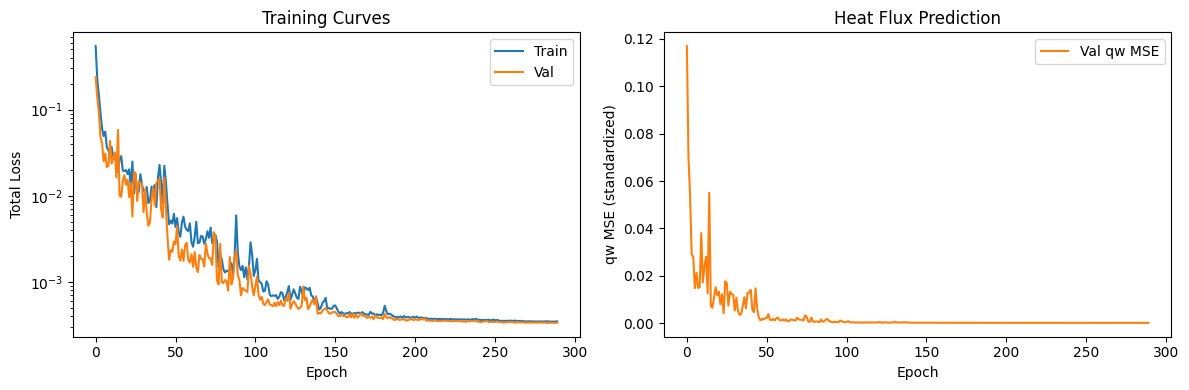

In [12]:
# ============================================================
# Cell 9: Training Curves
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Training Curves')
axes[0].legend()
axes[0].set_yscale('log')

if any(v > 0 for v in history['val_qw_mse']):
    axes[1].plot(history['val_qw_mse'], label='Val qw MSE', color='tab:orange')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('qw MSE (standardized)')
    axes[1].set_title('Heat Flux Prediction')
    axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# Cell 10: Evaluation — Metrics Matching Original Autoencoder
# ============================================================

@torch.no_grad()
def evaluate_model(model, dl, scaler_y, y_col_names, Y_raw):
    """
    Evaluate model and compute per-output metrics in physical units.
    Matches the evaluation format from the original autoencoder notebook.
    """
    model.eval()
    all_preds = {name: [] for name in y_col_names}

    for X_batch, Y_batch in dl:
        X_batch = X_batch.to(device)
        out = model(X_batch)
        for name in y_col_names:
            if name in out:
                all_preds[name].append(out[name].cpu().numpy())

    results = {}
    for i, name in enumerate(y_col_names):
        # Concatenate predictions: (n_solutions, seq_len, 1)
        pred_std = np.concatenate(all_preds[name], axis=0)  # (N_sol, L, 1)

        # Inverse transform: standardized → log10 → physical
        pred_flat = pred_std.reshape(-1, 1)
        # Manual inverse: only for this output column
        pred_log = pred_flat * scaler_y.scale_[i] + scaler_y.mean_[i]
        pred_phys = np.power(10.0, pred_log).ravel()

        # Ground truth in physical units
        true_phys = Y_raw[:, :, i].ravel()

        # Relative errors
        rel_errors = np.abs(true_phys - pred_phys) / (true_phys + 1e-9) * 100

        mae  = mean_absolute_error(true_phys, pred_phys)
        rmse = np.sqrt(mean_squared_error(true_phys, pred_phys))

        results[name] = {
            'mae': mae,
            'rmse': rmse,
            'pct_1':  (rel_errors <= 1).mean() * 100,
            'pct_3':  (rel_errors <= 3).mean() * 100,
            'pct_5':  (rel_errors <= 5).mean() * 100,
            'pct_10': (rel_errors <= 10).mean() * 100,
            'median_err': float(np.median(rel_errors)),
            'q95_err': float(np.percentile(rel_errors, 95)),
            'rel_errors': rel_errors,
            'pred_phys': pred_phys,
            'true_phys': true_phys,
        }

    return results


# Run evaluation
test_results = evaluate_model(model, test_dl, scaler_y, y_col_names, Y_test_raw)

# Print results (same format as original autoencoder)
output_labels = {'qw': 'Heat Flux qw (W/m\u00b2)', 'pw': 'Pressure pw (Pa)', 'tw': 'Shear Stress \u03c4w (Pa)'}

for name in y_col_names:
    r = test_results[name]
    print("\n" + "=" * 60)
    print(f"  {output_labels.get(name, name)} — {cfg.block_type.upper()} RESULTS")
    print("=" * 60)
    print(f"  MAE:          {r['mae']:,.0f}")
    print(f"  RMSE:         {r['rmse']:,.0f}")
    print(f"  Within \u00b11%:   {r['pct_1']:.1f}%")
    print(f"  Within \u00b13%:   {r['pct_3']:.1f}%")
    print(f"  Within \u00b15%:   {r['pct_5']:.1f}%")
    print(f"  Within \u00b110%:  {r['pct_10']:.1f}%")
    print(f"  Median error:  {r['median_err']:.2f}%")
    print(f"  95th %%ile:    {r['q95_err']:.1f}%")


  Heat Flux qw (W/m²) — MAMBA3 RESULTS
  MAE:          7,841
  RMSE:         15,747
  Within ±1%:   46.5%
  Within ±3%:   86.0%
  Within ±5%:   94.4%
  Within ±10%:  99.7%
  Median error:  1.10%
  95th %%ile:    5.3%


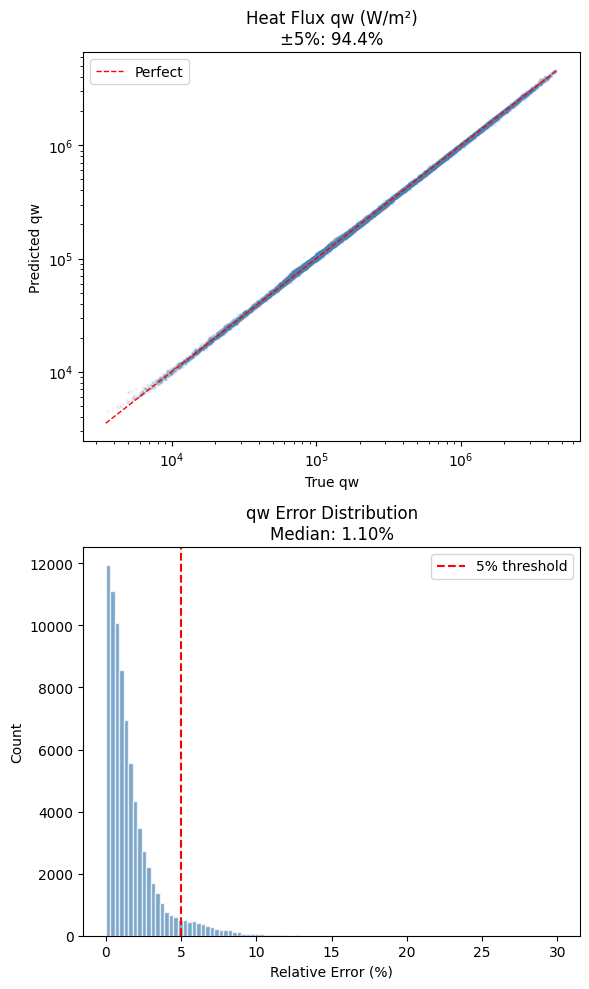

In [14]:
# ============================================================
# Cell 11: Visualization — Predicted vs True & Error Distributions
# ============================================================

n_outputs = len(y_col_names)
fig, axes = plt.subplots(2, n_outputs, figsize=(6 * n_outputs, 10))
if n_outputs == 1:
    axes = axes.reshape(-1, 1)

for i, name in enumerate(y_col_names):
    r = test_results[name]

    # Scatter: predicted vs true
    ax = axes[0, i]
    sample_idx = np.random.choice(len(r['true_phys']),
                                  min(50000, len(r['true_phys'])), replace=False)
    ax.scatter(r['true_phys'][sample_idx], r['pred_phys'][sample_idx],
               alpha=0.1, s=1, color='steelblue')
    lims = [min(r['true_phys'].min(), r['pred_phys'].min()),
            max(r['true_phys'].max(), r['pred_phys'].max())]
    ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect')
    ax.set_xlabel(f'True {name}')
    ax.set_ylabel(f'Predicted {name}')
    ax.set_title(f'{output_labels.get(name, name)}\n\u00b15%: {r["pct_5"]:.1f}%')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend()

    # Error distribution
    ax = axes[1, i]
    ax.hist(r['rel_errors'], bins=100, range=(0, 30),
            color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(5, color='red', linestyle='--', label='5% threshold')
    ax.set_xlabel('Relative Error (%)')
    ax.set_ylabel('Count')
    ax.set_title(f'{name} Error Distribution\nMedian: {r["median_err"]:.2f}%')
    ax.legend()

plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# Cell 12: Ablation — Quick Comparison of Block Types
#
# Uncomment and run to compare mamba2 vs mamba3 vs mlp.
# This retrains from scratch with each config.
# ============================================================

# ablation_configs = [
#     Config(block_type='mlp',   use_rope=False, use_trapezoidal=False, epochs=50),
#     Config(block_type='mamba2', use_rope=False, use_trapezoidal=False, epochs=50),
#     Config(block_type='mamba3', use_rope=True,  use_trapezoidal=False, epochs=50),  # RoPE only
#     Config(block_type='mamba3', use_rope=True,  use_trapezoidal=True,  epochs=50),  # Full Mamba-3
# ]
#
# ablation_results = {}
# for ab_cfg in ablation_configs:
#     label = f"{ab_cfg.block_type}"
#     if ab_cfg.block_type == 'mamba3':
#         label += f"_rope={ab_cfg.use_rope}_trap={ab_cfg.use_trapezoidal}"
#     print(f"\n{'='*40}\nTraining: {label}\n{'='*40}")
#
#     ab_model = MambaAutoencoder(ab_cfg).to(device)
#     ab_opt = torch.optim.AdamW(ab_model.parameters(), lr=ab_cfg.lr, weight_decay=ab_cfg.weight_decay)
#     # ... (training loop from Cell 8, abbreviated)
#     ab_results = evaluate_model(ab_model, test_dl, scaler_y, y_col_names, Y_test_raw)
#     ablation_results[label] = {name: ab_results[name]['pct_5'] for name in y_col_names}
#     print(f"{label}: " + ", ".join(f"{n} ±5%={ablation_results[label][n]:.1f}%" for n in y_col_names))
#
# # Print comparison table
# print("\n" + "="*60)
# print(f"{'Model':<35} | " + " | ".join(f"{n} ±5%" for n in y_col_names))
# print("-"*60)
# for label, res in ablation_results.items():
#     vals = " | ".join(f"{res[n]:6.1f}%" for n in y_col_names)
#     print(f"{label:<35} | {vals}")

## Architecture Summary

```
Input: (batch, 4096 points, 7 features)
  │
  ├─ Input Projection ──→ (batch, 4096, d_model=64)
  │
  ├─ Mamba Block 1 (SelectiveSSM + residual)
  │   ├─ Causal Conv1d
  │   ├─ SSM: B,C,Δ projected from input (data-dependent)
  │   ├─ [Mamba-3] BC bias (learned, init=1)
  │   ├─ [Mamba-3] RoPE on B,C (complex-valued state)
  │   ├─ [Mamba-3] Trapezoidal scan (h_t = α*h + β*Bx_prev + γ*Bx)
  │   └─ SiLU gating + output projection
  ├─ Mamba Block 2
  ├─ Mamba Block 3
  ├─ Mamba Block 4
  │
  ├─ Latent bottleneck ──→ (batch, 4096, latent_dim=16)
  │
  ├─ Reconstruction Head ──→ (batch, 4096, 7)     [autoencoder loss]
  ├─ qw Head ──→ (batch, 4096, 1)                 [heat flux]
  ├─ pw Head ──→ (batch, 4096, 1)                 [pressure]
  └─ τw Head ──→ (batch, 4096, 1)                 [shear stress]
        │
        └─ Physics Loss: Reynolds analogy + smoothness + consistency
```

### Extensibility

To upgrade to official Mamba-3 when released:
```python
# In Config, change:
cfg.block_type = "mamba3_official"

# In MambaAutoencoder.__init__, add:
elif config.block_type == 'mamba3_official':
    from mamba_ssm import Mamba3  # when available
    self.encoder = nn.Sequential(*[
        Mamba3(d_model=d, d_state=config.d_state)
        for _ in range(config.n_layers)
    ])
```